In [120]:
import os
import random
import pickle
import numpy as np
import kagglehub
from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split, Subset

In [121]:
# 난수 생성의 기준값(Seed) 설정
# 같은 Seed를 사용하면 매번 동일한 난수가 생성되어 실험을 재현할 수 있음
SEED = 42

# Python 기본 random 라이브러리의 난수 생성 Seed 설정
random.seed(SEED)

# NumPy의 난수 생성 Seed 설정
np.random.seed(SEED)

# PyTorch(CPU)의 난수 생성 Seed 설정
# 가중치 초기화, 데이터 섞기(shuffle) 등 CPU에서 발생하는 난수에 적용
torch.manual_seed(SEED)

# CUDA(GPU)를 사용할 수 있는지 확인
if torch.cuda.is_available():
    # 현재 GPU의 난수 생성 Seed 설정
    torch.cuda.manual_seed(SEED)

    # 여러 개의 GPU를 사용하는 경우 모든 GPU의 Seed를 동일하게 설정
    torch.cuda.manual_seed_all(SEED)

# cuDNN이 항상 동일한 결과를 내는 알고리즘만 사용하도록 설정
# 실행 속도는 다소 느려질 수 있지만 결과를 재현할 수 있음
torch.backends.cudnn.deterministic = True

# 입력 크기에 따라 가장 빠른 알고리즘을 자동 탐색하는 기능 비활성화
# True이면 속도는 빨라질 수 있지만 실행마다 다른 알고리즘이 선택되어
# 결과가 조금씩 달라질 수 있으므로 재현성을 위해 False로 설정
torch.backends.cudnn.benchmark = False

In [122]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)
print("PyTorch :", torch.__version__)

if torch.cuda.is_available():
    print("CUDA :", torch.version.cuda)
    print(torch.cuda.get_device_name(0))

Device : cuda
PyTorch : 2.12.1+cu132
CUDA : 13.2
NVIDIA GeForce RTX 3080


In [123]:
path = kagglehub.dataset_download("fedesoriano/cifar100")

print(path)
print(os.listdir(path))

/root/.cache/kagglehub/datasets/fedesoriano/cifar100/versions/1
['file.txt', 'meta', 'train', 'test']


In [124]:
class CustomCIFAR100(Dataset):
    def __init__(self, root, train=True, transform=None):

        self.transform = transform

        filename = "train" if train else "test"

        with open(os.path.join(root, filename), "rb") as f:
            entry = pickle.load(f, encoding="latin1")

        self.data = entry["data"]
        self.labels = entry["fine_labels"]

        # (N,3072)
        # -> (N,3,32,32)
        self.data = self.data.reshape(-1, 3, 32, 32)

        # (N,3,32,32)
        # -> (N,32,32,3)
        self.data = self.data.transpose((0, 2, 3, 1))

        with open(os.path.join(root, "meta"), "rb") as f:
            meta = pickle.load(f, encoding="latin1")

        self.classes = meta["fine_label_names"]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = Image.fromarray(self.data[idx])
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [125]:
MEAN = (0.5071, 0.4867, 0.4408)
STD = (0.2675, 0.2565, 0.2761)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomCrop(224, padding=16),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(               # 순서 중요 (PIL Image가 아니라 Tensor를 입력으로 받는다)
        p=0.25,
        scale=(0.02, 0.15)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])


In [126]:
train_dataset = CustomCIFAR100(
    root=path,
    train=True,
    transform=train_transform
)

val_dataset = CustomCIFAR100(
    root=path,
    train=True,
    transform=test_transform
)

test_dataset = CustomCIFAR100(
    root=path,
    train=False,
    transform=test_transform
)

In [127]:
train_size = int(len(train_dataset) * 0.9)
val_size = len(train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(len(train_dataset), generator=generator)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_data = Subset(train_dataset, train_indices)
val_data = Subset(val_dataset, val_indices)

In [128]:
train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=128,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    # num_workers=4,        # 데이터를 읽는 Worker(Process) 개수
    pin_memory=True         # CPU 메모리를 Pinned Memory(Page-Locked Memory)로 할당, images = images.to(device)를 실행할 때 CPU → GPU 전송 속도를 높여 줍니다
)

In [129]:
print("Train Dataset :", len(train_dataset))
print("Validation :", len(val_data))
print("Test Dataset :", len(test_dataset))
print("Number of Classes :", len(train_dataset.classes))

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

Train Dataset : 50000
Validation : 5000
Test Dataset : 10000
Number of Classes : 100
torch.Size([128, 3, 224, 224])
torch.Size([128])


In [130]:
weights = models.ResNet34_Weights.IMAGENET1K_V1

resnet = models.resnet34(weights=weights)

print("Original FC")
print(resnet.fc)

num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 100)

resnet = resnet.to(device)

print("\nModified FC")
print(resnet.fc)

Original FC
Linear(in_features=512, out_features=1000, bias=True)

Modified FC
Linear(in_features=512, out_features=100, bias=True)


In [131]:
# # layer1, layer2는 ImageNet 특징 유지
# for param in resnet.layer1.parameters():
#     param.requires_grad = False

# for param in resnet.layer2.parameters():
#     param.requires_grad = False

# # layer3부터 CIFAR에 적응
# for param in resnet.layer3.parameters():
#     param.requires_grad = True

# for param in resnet.layer4.parameters():
#     param.requires_grad = True

# for param in resnet.fc.parameters():
#     param.requires_grad = True

for param in resnet.parameters():
    param.requires_grad = True

In [132]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1  # 정답 클래스의 확률을 0.9정도로 낮추고, 나머지 클래스에 0.1을 나누어 분배하여 과적합 줄임
)

optimizer = torch.optim.SGD(
    [
        { "params": resnet.parameters(), "lr": 1e-2 },
    ]
    , momentum=0.9      # 이전 기울기를 일부 반영하여 더 빠르고 안정적으로 최적점을 찾음
    , weight_decay=1e-3 # 큰 가중치가 생기는 것을 방지하여 과적합(Overfitting)을 줄임
)        

In [ ]:
# Learning Rate Scheduler
epochs = 40

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

# Mixed Precision
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

In [134]:
# Early Stopping
patience = 5

counter = 0

best_val_acc = 0.0
best_val_loss = float("inf")

In [135]:
# History
train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [136]:
# Model Information
print(resnet)

print()

trainable = sum(
    p.numel()
    for p in resnet.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in resnet.parameters()
)

print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
# epochs 횟수만큼 전체 학습 반복
for epoch in range(epochs):

    # ============================
    # Train Mode
    # ============================
    resnet.train()
    # 모델을 학습 모드로 변경
    # Dropout, BatchNorm 등이 학습 방식으로 동작

    train_loss = 0.0      # Epoch 동안의 총 Train Loss
    train_correct = 0     # 맞춘 이미지 개수
    train_total = 0       # 전체 이미지 개수

    # train_loader에서 Batch 단위로 데이터 가져오기
    for images, labels in train_loader:

        # 이미지를 GPU(CUDA) 또는 CPU로 이동
        # non_blocking=True는 pin_memory=True와 함께 사용하면
        # CPU → GPU 전송을 비동기로 수행하여 속도를 향상시킴
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # 이전 Batch에서 계산된 Gradient 초기화
        optimizer.zero_grad()

        # Mixed Precision(자동 혼합 정밀도) 시작
        # CUDA 사용 시 일부 연산을 float16으로 수행하여
        # 메모리 사용량 감소 및 학습 속도 향상
        with torch.autocast(
            device_type=device.type,
            enabled=torch.cuda.is_available()
        ):
            # Forward Propagation
            # 입력 이미지를 모델에 통과시켜 예측값(Logits) 계산
            outputs = resnet(images)

            # 예측값과 정답을 이용하여 Loss 계산
            loss = criterion(outputs, labels)

        # Loss를 Scale하여 작은 Gradient가 0이 되는 것을 방지
        scaler.scale(loss).backward()

        # Optimizer가 Scale된 Gradient를 이용하여 Weight 업데이트
        scaler.step(optimizer)

        # Scale 값 자동 조정
        scaler.update()

        # Batch Loss 누적
        train_loss += loss.item()

        # 가장 큰 Logit 값을 가진 클래스 선택
        # "_" : 최대값(Logit)
        # predicted : 최대값의 인덱스(예측 클래스)
        _, predicted = torch.max(outputs, 1)

        # 현재 Batch의 이미지 개수 누적
        train_total += labels.size(0)

        # 맞춘 개수 누적
        train_correct += (predicted == labels).sum().item()

    # Epoch 평균 Loss 계산
    train_loss /= len(train_loader)

    # Epoch Accuracy 계산(%)
    train_acc = 100 * train_correct / train_total

    # ============================
    # Validation Mode
    # ============================
    resnet.eval()
    # 평가 모드로 변경
    # Dropout 비활성화
    # BatchNorm은 저장된 평균과 분산 사용

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Validation에서는 Gradient 계산 비활성화
    # 메모리 절약 및 속도 향상
    with torch.no_grad():

        # Validation 데이터 반복
        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Validation도 Mixed Precision 사용
            with torch.autocast(
                device_type=device.type,
                enabled=torch.cuda.is_available()
            ):

                # Forward만 수행
                outputs = resnet(images)

                # Validation Loss 계산
                loss = criterion(outputs, labels)

            # Loss 누적
            val_loss += loss.item()

            # 가장 큰 확률의 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # Validation 이미지 개수 누적
            val_total += labels.size(0)

            # 맞춘 개수 누적
            val_correct += (predicted == labels).sum().item()

    # 평균 Validation Loss 계산
    val_loss /= len(val_loader)

    # Validation Accuracy 계산
    val_acc = 100 * val_correct / val_total

    # Learning Rate Scheduler 업데이트
    scheduler.step()

    # Loss 기록
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Accuracy 기록
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # 현재 Learning Rate 확인
    current_lr = optimizer.param_groups[0]["lr"]

    # 현재 Epoch 결과 출력
    print(
        f"Epoch [{epoch+1:03d}/{epochs}] "
        f"LR:{current_lr:.6f} | "
        f"Train Loss:{train_loss:.4f} "
        f"Train Acc:{train_acc:.2f}% | "
        f"Val Loss:{val_loss:.4f} "
        f"Val Acc:{val_acc:.2f}%"
    )

    # ============================
    # Early Stopping
    # ============================

    # Validation Accuracy가 향상되었거나,
    # Accuracy가 같지만 Loss가 감소했다면
    if (
        val_acc > best_val_acc
        or
        (
            val_acc == best_val_acc
            and val_loss < best_val_loss
        )
    ):

        # Early Stopping 카운터 초기화
        counter = 0

        # 가장 성능이 좋은 모델 저장
        torch.save(
            resnet.state_dict(),
            "best_model.pth"
        )

        best_val_acc = val_acc
        best_val_loss = val_loss

    else:
        # 성능이 향상되지 않았으므로 카운터 증가
        counter += 1

    # patience 이상 성능 향상이 없으면 학습 종료
    if counter >= patience:
        print()
        print("Early Stopping")
        break

Epoch [001/30] LR:0.009973 | Train Loss:2.2233 Train Acc:56.65% | Val Loss:1.5934 Val Acc:73.66%
Epoch [002/30] LR:0.009891 | Train Loss:1.5338 Train Acc:76.43% | Val Loss:1.4948 Val Acc:77.12%
Epoch [003/30] LR:0.009755 | Train Loss:1.3833 Train Acc:81.48% | Val Loss:1.4790 Val Acc:77.32%
Epoch [004/30] LR:0.009568 | Train Loss:1.2935 Train Acc:84.50% | Val Loss:1.4006 Val Acc:80.30%
Epoch [005/30] LR:0.009330 | Train Loss:1.2236 Train Acc:87.10% | Val Loss:1.4355 Val Acc:78.78%
Epoch [006/30] LR:0.009045 | Train Loss:1.1665 Train Acc:89.16% | Val Loss:1.3961 Val Acc:80.20%
Epoch [007/30] LR:0.008716 | Train Loss:1.1138 Train Acc:91.06% | Val Loss:1.3708 Val Acc:81.44%
Epoch [008/30] LR:0.008346 | Train Loss:1.0815 Train Acc:92.06% | Val Loss:1.3915 Val Acc:80.00%
Epoch [009/30] LR:0.007939 | Train Loss:1.0418 Train Acc:93.50% | Val Loss:1.3486 Val Acc:81.88%
Epoch [010/30] LR:0.007500 | Train Loss:1.0178 Train Acc:94.17% | Val Loss:1.3532 Val Acc:81.82%
Epoch [011/30] LR:0.007034 | T

In [ ]:
# Load Best Model
print("\nLoading Best Model...\n")
resnet.load_state_dict(torch.load("best_model.pth"))
resnet.eval()


Loading Best Model...



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
# Test
test_loss = 0.0

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(
            device_type=device.type,
            enabled=torch.cuda.is_available()
        ):
            outputs = resnet(images)
            loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_loss /= len(test_loader)
test_acc = 100 * correct / total

print("=" * 60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2f}%")
print("=" * 60)

Test Loss     : 1.3068
Test Accuracy : 84.09%


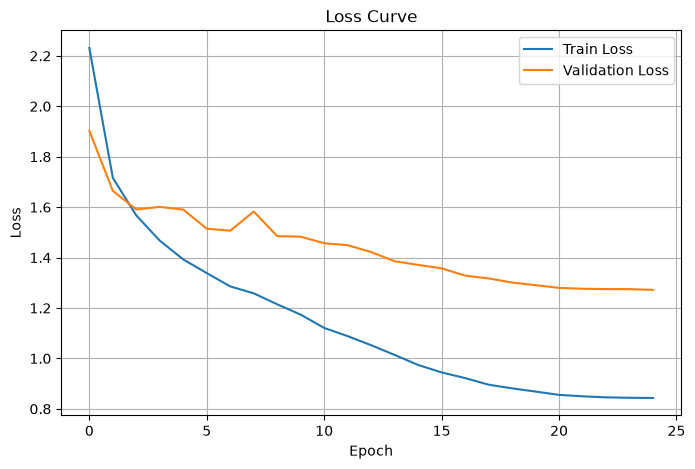

In [ ]:
# Loss Curve
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curve")

plt.grid(True)

plt.legend()

plt.show()


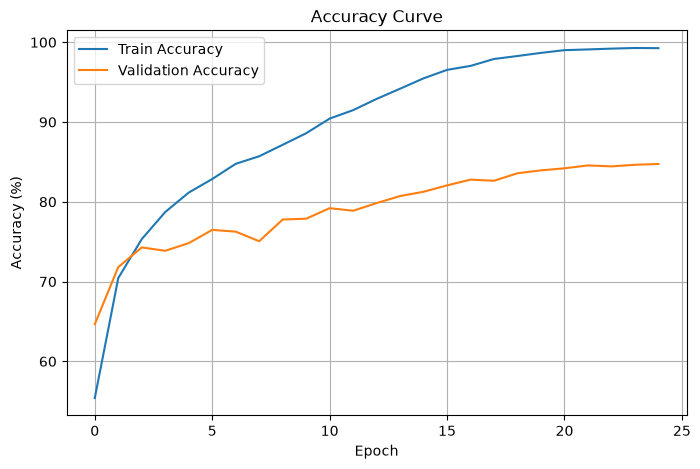

In [ ]:
# Accuracy Curve
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Accuracy Curve")

plt.grid(True)

plt.legend()

plt.show()

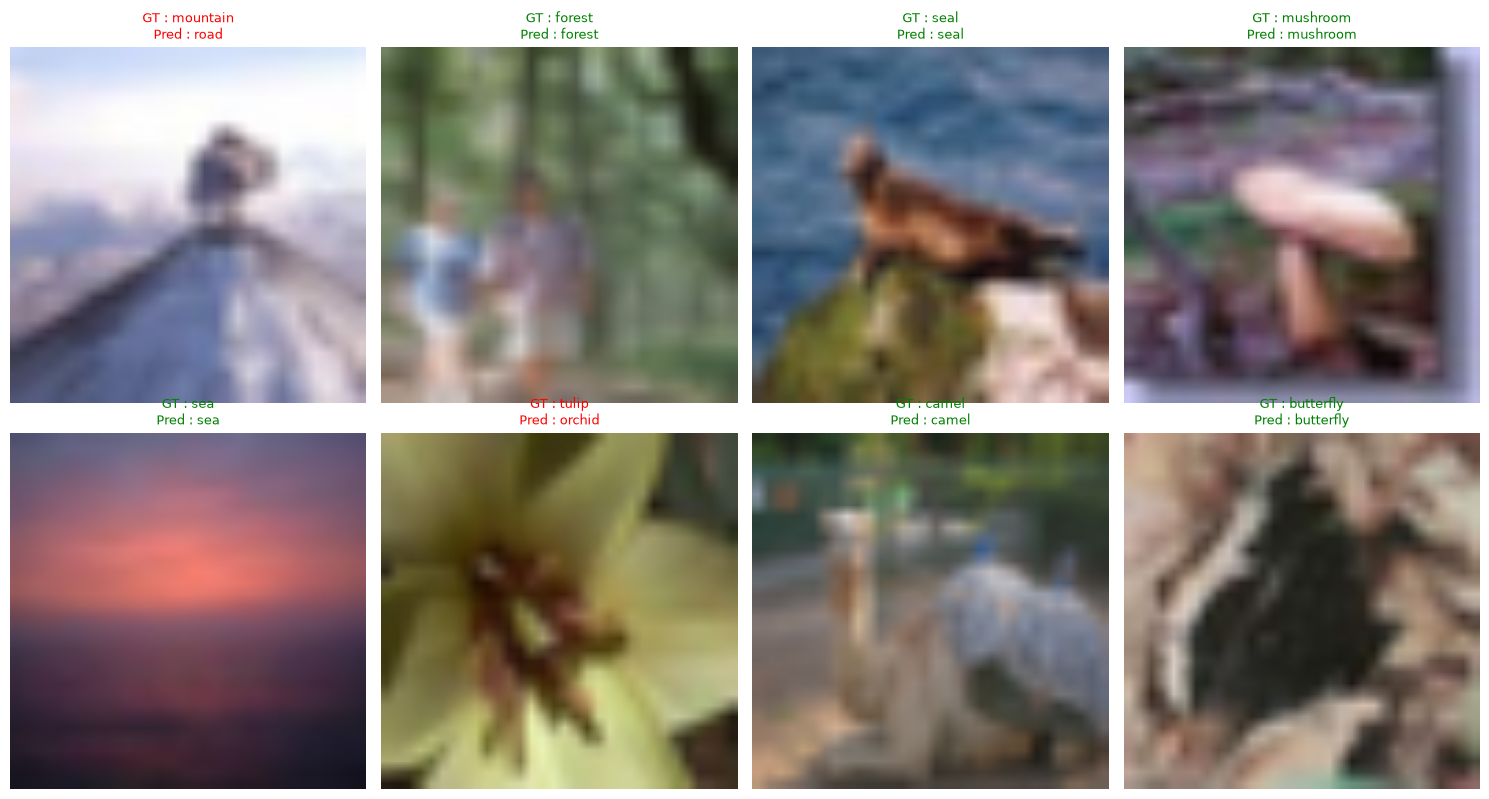

In [ ]:
# Prediction Visualization
classes = train_dataset.classes

images, labels = next(iter(test_loader))

images_gpu = images.to(device)

resnet.eval()

with torch.no_grad():

    outputs = resnet(images_gpu)

    _, predicted = torch.max(outputs, 1)

predicted = predicted.cpu()

# Normalize 복원
mean = torch.tensor(MEAN).view(3,1,1)
std = torch.tensor(STD).view(3,1,1)

plt.figure(figsize=(15,8))

for i in range(8):

    img = images[i] * std + mean
    img = img.clamp(0,1)

    plt.subplot(2,4,i+1)

    plt.imshow(img.permute(1,2,0))

    color = "green" if predicted[i] == labels[i] else "red"

    plt.title(
        f"GT : {classes[labels[i]]}\n"
        f"Pred : {classes[predicted[i]]}",
        fontsize=9,
        color=color
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
print("\nTraining Finished.")


Training Finished.
